### 1. 패키지 설치

In [10]:
%pip install -qU langgraph 

Note: you may need to restart the kernel to use updated packages.


### 2. 조건부 분기(결제 흐름) 구현법
- `pg` 노드가 먼저 실행되어 어떤 결제수단으로 보낼지(`method`) 결정함
- `route` 함수는 state를 보고 **다음 노드 이름**을 반환 → `add_conditional_edges`로 연결
- `toss` / `kakao` / `naver` 중 하나만 실행된 뒤 `settlement`로 합류 (결제수단은 1개만 선택되므로 조건 분기)
- 지원하지 않는 `method`나 값 누락은 `fail` 노드로 보내 런타임 에러 없이 처리

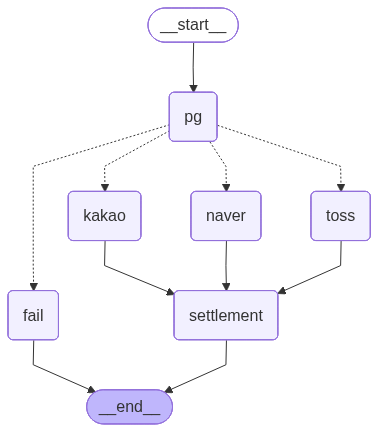

In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

METHODS = ('toss', 'kakao', 'naver')   # 지원하는 결제수단

class State(TypedDict):
    method: str      # 분기 기준 (toss / kakao / naver)
    amount: int      # 결제 금액
    result: str      # 결제 처리 결과

def pg(state: State):       # 먼저 실행 → 결제 요청 접수
    amount = state.get('amount', 0)
    print('pg 함수 실행 - 결제 요청 접수')
    return {'result': f"{amount}원 결제 요청"}

def toss(state: State):
    print('toss 함수 실행')
    return {'result': 'toss 결제 완료'}

def kakao(state: State):
    print('kakao 함수 실행')
    return {'result': 'kakao 결제 완료'}

def naver(state: State):
    print('naver 함수 실행')
    return {'result': 'naver 결제 완료'}

def fail(state: State):     # 지원하지 않는 결제수단 처리
    print('fail 함수 실행 - 지원하지 않는 결제수단')
    return {'result': f"결제 실패: 지원하지 않는 결제수단({state.get('method')})"}

def settlement(state: State):  # 정상 분기 후 합류 → 결제 정산
    print('settlement 함수 실행 - 결제 정산')
    return {'result': f"정산 완료 <- {state['result']}"}

def route(state: State) -> Literal['toss', 'kakao', 'naver', 'fail']:  # 반환값 = 다음 노드 이름
    method = state.get('method')
    return method if method in METHODS else 'fail'   # 미지원 값은 fail로

graph = StateGraph(State)

graph.add_node('pg', pg)
graph.add_node('toss', toss)
graph.add_node('kakao', kakao)
graph.add_node('naver', naver)
graph.add_node('fail', fail)
graph.add_node('settlement', settlement)

graph.add_edge(START, 'pg')
graph.add_conditional_edges('pg', route)   # pg 결과(method)로 toss / kakao / naver / fail 분기
graph.add_edge('toss', 'settlement')       # 정상 분기는 settlement로 합류
graph.add_edge('kakao', 'settlement')
graph.add_edge('naver', 'settlement')
graph.add_edge('settlement', END)
graph.add_edge('fail', END)                # 실패는 정산 없이 종료

app = graph.compile()

app

### 3. 실행 (invoke)
- `pg → (toss | kakao | naver) → settlement` 순서로 결제 흐름 실행
- `method` 값에 따라 어떤 결제수단으로 분기될지 갈리고 결과는 `settlement`에서 정산됨
- 미지원 `method`(예: `'apple'`)나 값 누락 시 `fail`로 분기되어 에러 없이 종료

In [8]:
app.invoke({'method': 'kakao', 'amount': 10000})   # method 값에 따라 toss / kakao / naver 분기

pg 함수 실행 - 결제 요청 접수
kakao 함수 실행
settlement 함수 실행 - 결제 정산


{'method': 'kakao', 'amount': 10000, 'result': '정산 완료 <- kakao 결제 완료'}

In [9]:
app.invoke({'method': 'apple', 'amount': 10000})

pg 함수 실행 - 결제 요청 접수
fail 함수 실행 - 지원하지 않는 결제수단


{'method': 'apple', 'amount': 10000, 'result': '결제 실패: 지원하지 않는 결제수단(apple)'}